Name: Eric Baah
Course: MAT 443
Homework 8
Date: 11/16/2024

In [151]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, cm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from ISLP import load_data
import warnings
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from ISLP.models import (ModelSpec as MS, summarize, poly)
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor as XGB
from lightgbm import LGBMRegressor as LGBMR
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report
import seaborn as sns
import patsy as pt
from sklearn import preprocessing
from sklearn.datasets import make_moons, make_classification
from sklearn import svm
from sklearn.model_selection import cross_val_score
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

### Question 9.3


We are given a dataset with $n = 7$ observations in $p = 2$ dimensions. Each observation has an associated class label.

\begin{array}{|c|c|c|c|}
\hline
\text{Obs.} & X_1 & X_2 & Y \\
\hline
1 & 3 & 4 & \text{Red} \\
2 & 2 & 2 & \text{Red} \\
3 & 4 & 4 & \text{Red} \\
4 & 1 & 4 & \text{Red} \\
5 & 2 & 1 & \text{Blue} \\
6 & 4 & 3 & \text{Blue} \\
7 & 4 & 1 & \text{Blue} \\
\hline
\end{array}


(a) Sketch the observations 

The observations can be plotted in the $(X_1, X_2)$-plane, where points with the label $\textbf{Red}$ represent one class, and points with the label $\textbf{Blue}$ represent the other class.


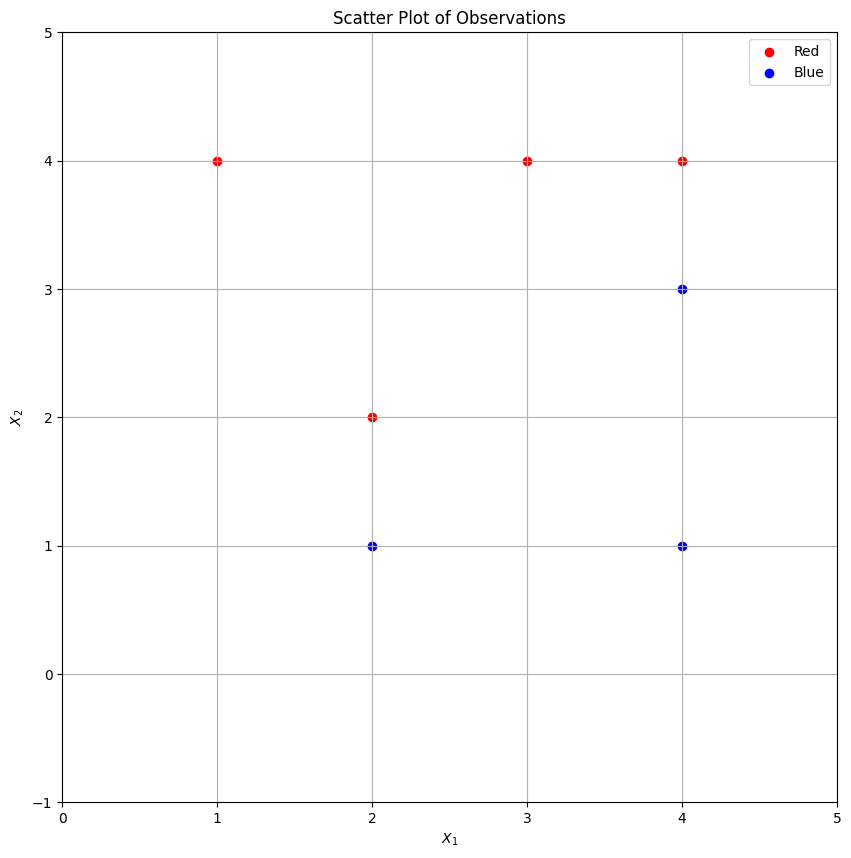

In [44]:
# Part (a)
# Data
data = {
    'X1': [3, 2, 4, 1, 2, 4, 4],
    'X2': [4, 2, 4, 4, 1, 3, 1],
    'Y': ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']
}
df = pd.DataFrame(data)

# Map labels to numeric values
df['Y_num'] = df['Y'].map({'Red': 1, 'Blue': -1})

# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Scatter Plot of Observations')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()


(b) Sketch the optimal separating hyperplane and provide the equation 

The optimal separating hyperplane is chosen such that it maximizes the margin between the two classes. For this dataset, the hyperplane can be found by maximizing the distance to the closest points in both classes.

Assume the optimal hyperplane has the form:
$\beta_0 + \beta_1 X_1 + \beta_2 X_2 = 0 $



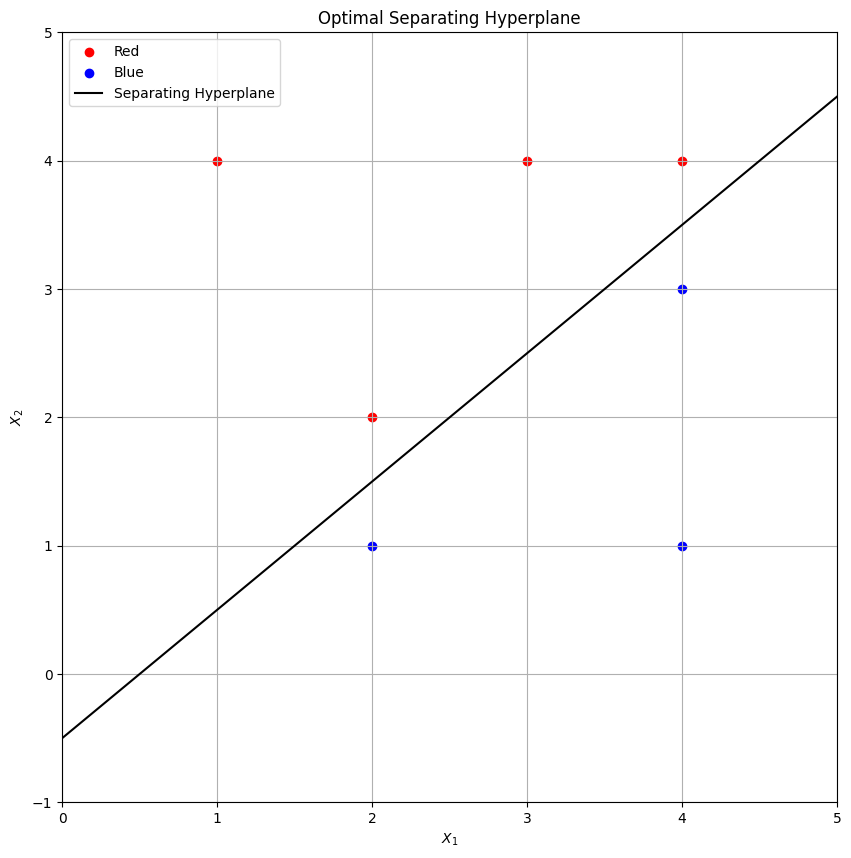

In [45]:
#Part (b)
# Prepare data for SVM
X = df[['X1', 'X2']].values
y = df['Y_num'].values

# Train the maximal margin classifier (SVM with linear kernel and high C)
model = SVC(kernel='linear', C=1e5)
model.fit(X, y)

# Get the separating hyperplane
w = model.coef_[0]
b = model.intercept_[0]
slope = -w[0] / w[1]
intercept = -b / w[1]

# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')

# Plot the separating hyperplane
x_vals = np.array([0, 5])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, 'k-', label='Separating Hyperplane')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Optimal Separating Hyperplane')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()

(c) Classification Rule for the Maximal Margin Classifier 

The classification rule would be:
$\text{Classify as Red if } -0.5 + X_1 - X_2 < 0, \text{ otherwise classify as Blue.}$

Values for the betas are: $\beta_0 = -0.5$, $\beta_1=1$, and $\beta_2=-1$

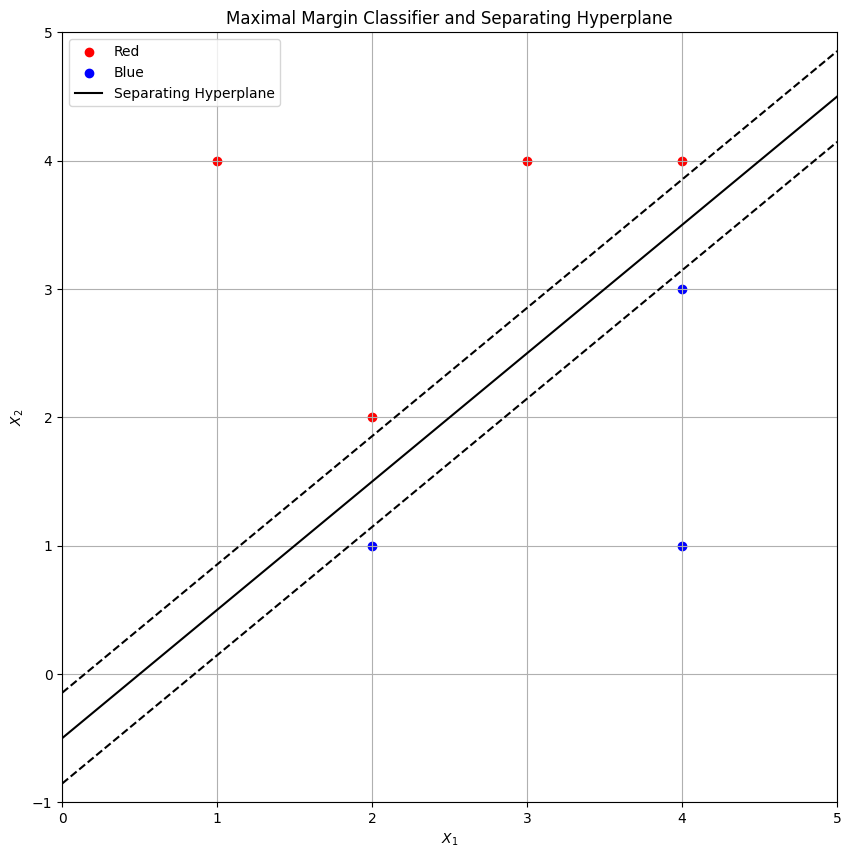

In [47]:
#Part (d)
# Prepare data for SVM
X = df[['X1', 'X2']].values
y = df['Y_num'].values

# Train the maximal margin classifier (SVM with linear kernel and high C)
model = SVC(kernel='linear', C=1e5)
model.fit(X, y)

# Get the separating hyperplane
w = model.coef_[0]
b = model.intercept_[0]
slope = -w[0] / w[1]
intercept = -b / w[1]

# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')

# Plot the separating hyperplane
x_vals = np.array([0, 5])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, 'k-', label='Separating Hyperplane')

# Margins
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_vals = slope * x_vals + intercept + margin
plt.plot(x_vals, yy_vals, 'k--')
yy_vals = slope * x_vals + intercept - margin
plt.plot(x_vals, yy_vals, 'k--')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Maximal Margin Classifier and Separating Hyperplane')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()

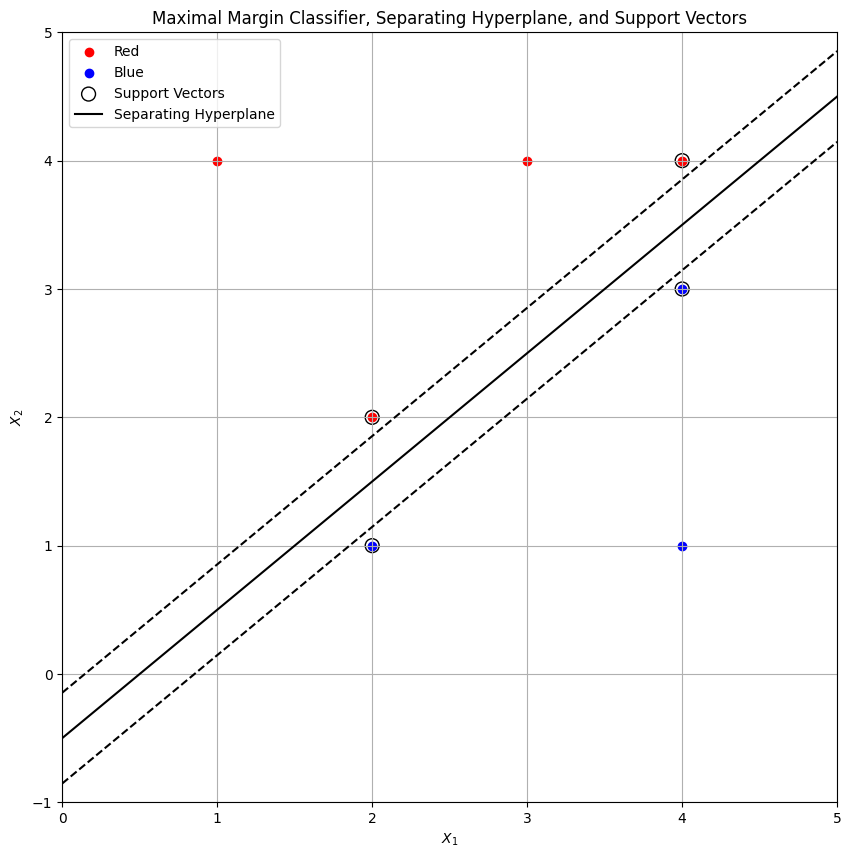

In [48]:
#Part (e)
# Prepare data for SVM
X = df[['X1', 'X2']].values
y = df['Y_num'].values

# Train the maximal margin classifier (SVM with linear kernel and high C)
model = SVC(kernel='linear', C=1e5)
model.fit(X, y)

# Get the separating hyperplane
w = model.coef_[0]
b = model.intercept_[0]
slope = -w[0] / w[1]
intercept = -b / w[1]

# Support vectors
support_vectors = model.support_vectors_

# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# Plot the separating hyperplane
x_vals = np.array([0, 5])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, 'k-', label='Separating Hyperplane')

# Margins
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_vals = slope * x_vals + intercept + margin
plt.plot(x_vals, yy_vals, 'k--')
yy_vals = slope * x_vals + intercept - margin
plt.plot(x_vals, yy_vals, 'k--')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Maximal Margin Classifier, Separating Hyperplane, and Support Vectors')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()

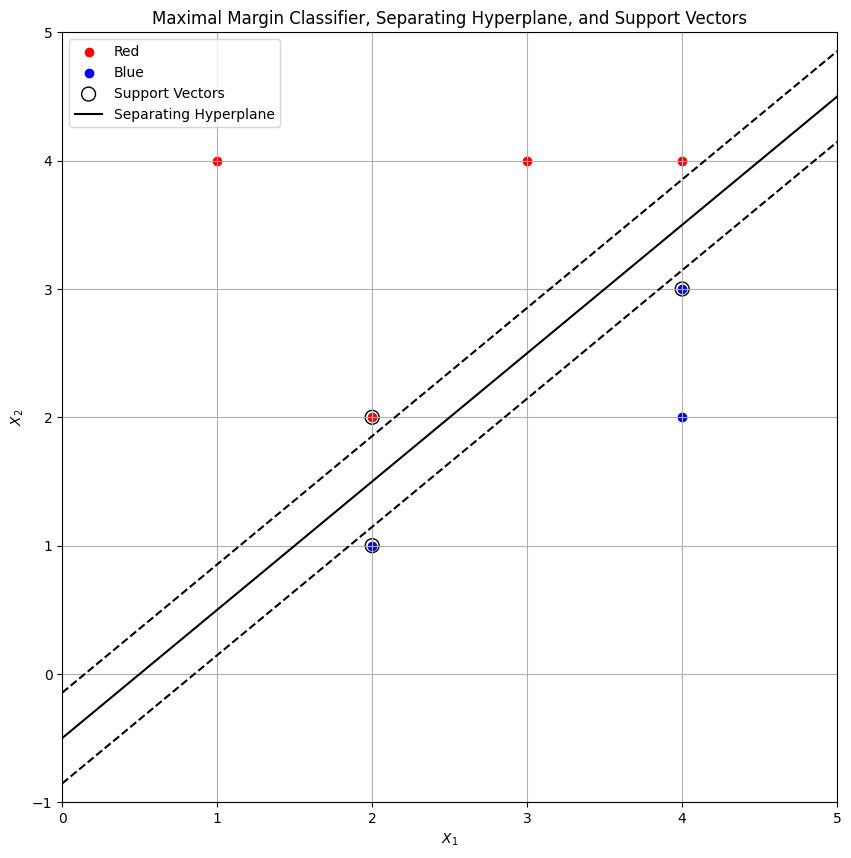

In [49]:
# Part (f)
# Data
data = {
    'X1': [3, 2, 4, 1, 2, 4, 4],
    'X2': [4, 2, 4, 4, 1, 3, 2],
    'Y': ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']
}
df = pd.DataFrame(data)

# Map labels to numeric values
df['Y_num'] = df['Y'].map({'Red': 1, 'Blue': -1})


# Prepare data for SVM
X = df[['X1', 'X2']].values
y = df['Y_num'].values

# Train the maximal margin classifier (SVM with linear kernel and high C)
model = SVC(kernel='linear', C=1e5)
model.fit(X, y)

# Get the separating hyperplane
w = model.coef_[0]
b = model.intercept_[0]
slope = -w[0] / w[1]
intercept = -b / w[1]

# Support vectors
support_vectors = model.support_vectors_

# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# Plot the separating hyperplane
x_vals = np.array([0, 5])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, 'k-', label='Separating Hyperplane')

# Margins
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_vals = slope * x_vals + intercept + margin
plt.plot(x_vals, yy_vals, 'k--')
yy_vals = slope * x_vals + intercept - margin
plt.plot(x_vals, yy_vals, 'k--')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Maximal Margin Classifier, Separating Hyperplane, and Support Vectors')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()


Clearly, changing the $7^{th}$ observation from $\{4,1,Blue\}$ to $\{4,2,Blue\}$ (increasing the $X_2$ value by 1) didn't change the maximal margin hyperplane. But increasing the $X_2$ value by, say 3, will change maximal margin hyperplane.

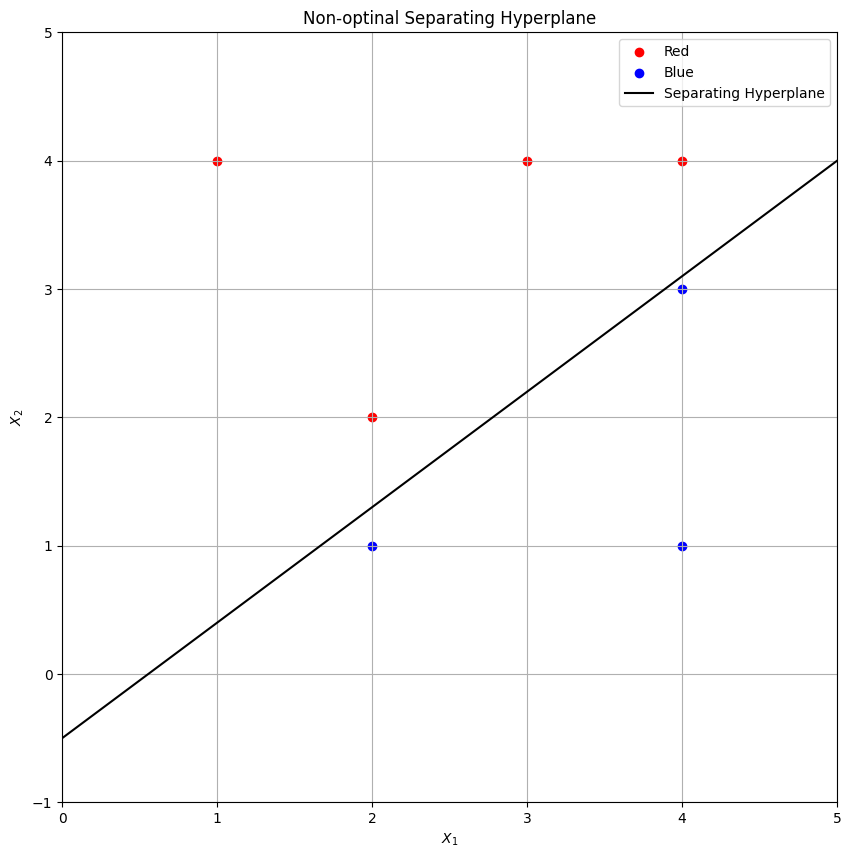

In [50]:
# Part (g)
# Data
data = {
    'X1': [3, 2, 4, 1, 2, 4, 4],
    'X2': [4, 2, 4, 4, 1, 3, 1],
    'Y': ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']
}
df = pd.DataFrame(data)

# Map labels to numeric values
df['Y_num'] = df['Y'].map({'Red': 1, 'Blue': -1})

# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')

# Plot the separating hyperplane
x_vals = np.array([0, 5])
y_vals = 0.9*x_vals - 0.5
plt.plot(x_vals, y_vals, 'k-', label='Separating Hyperplane')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Non-optinal Separating Hyperplane')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()


The equation for the above hyperplane is 
$ -0.5 + 0.9X_1 - X_2 =0$


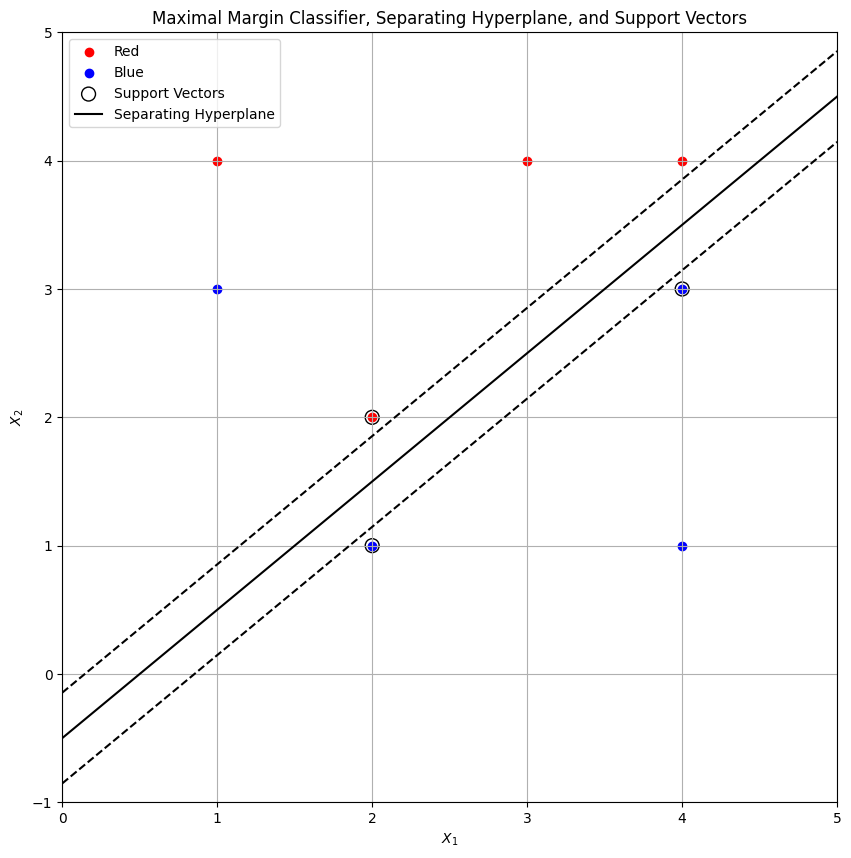

In [51]:
# Part (h)
# Data
data = {
    'X1': [3, 2, 4, 1, 2, 4, 4, 1],
    'X2': [4, 2, 4, 4, 1, 3, 1, 3],
    'Y': ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue', 'Blue']
}
df = pd.DataFrame(data)

# Map labels to numeric values
df['Y_num'] = df['Y'].map({'Red': 1, 'Blue': -1})


# Plot the data
plt.figure(figsize=(10, 10))
plt.scatter(df[df['Y'] == 'Red']['X1'], df[df['Y'] == 'Red']['X2'], color='red', label='Red')
plt.scatter(df[df['Y'] == 'Blue']['X1'], df[df['Y'] == 'Blue']['X2'], color='blue', label='Blue')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# Plot the separating hyperplane
x_vals = np.array([0, 5])
y_vals = x_vals - 0.5
plt.plot(x_vals, y_vals, 'k-', label='Separating Hyperplane')

# Margins
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_vals = slope * x_vals + intercept + margin
plt.plot(x_vals, yy_vals, 'k--')
yy_vals = slope * x_vals + intercept - margin
plt.plot(x_vals, yy_vals, 'k--')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.title('Maximal Margin Classifier, Separating Hyperplane, and Support Vectors')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(-1, 5)
plt.show()

### Question 9.5

In [231]:
# (a) Generate the dataset
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = (x1**2 - x2**2 > 0).astype(int)  # Create labels based on a quadratic decision boundary

X = np.column_stack((x1, x2))

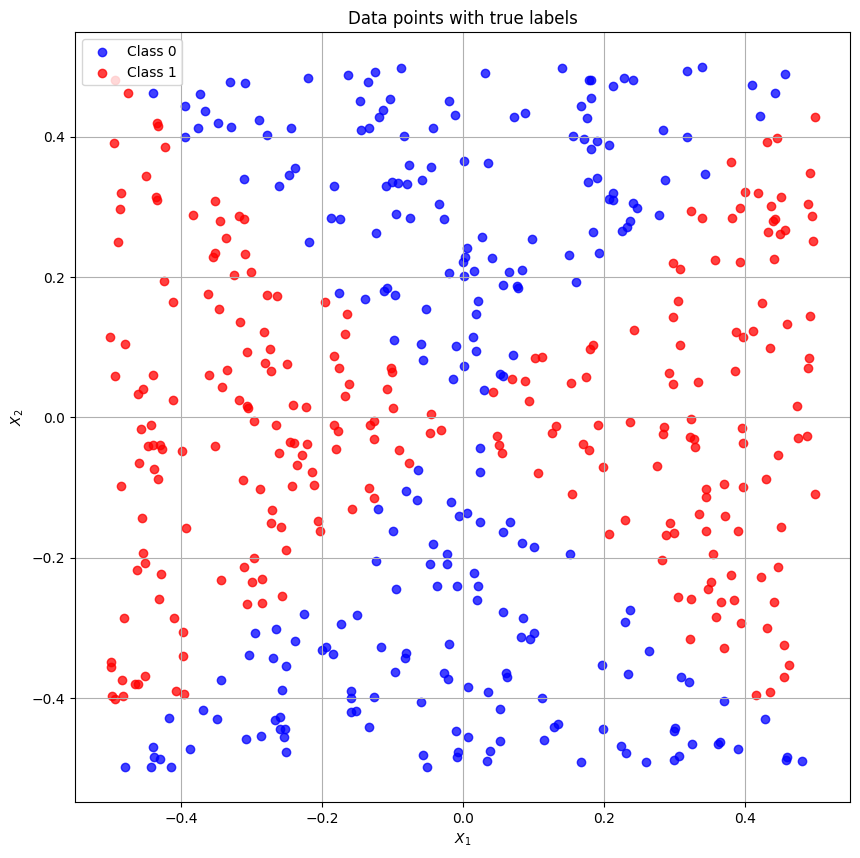

In [232]:

# (b) Plot the observations, colored according to their class labels
plt.figure(figsize=(10, 10))
plt.scatter(x1[y == 0], x2[y == 0], color='blue', label='Class 0', alpha= .75)
plt.scatter(x1[y == 1], x2[y == 1], color='red', label='Class 1', alpha= .75)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True)
plt.title('Data points with true labels')
plt.legend()
plt.show()


In [233]:

# (c) Fit logistic regression model with X1 and X2 as predictors

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)


LogisticRegression()

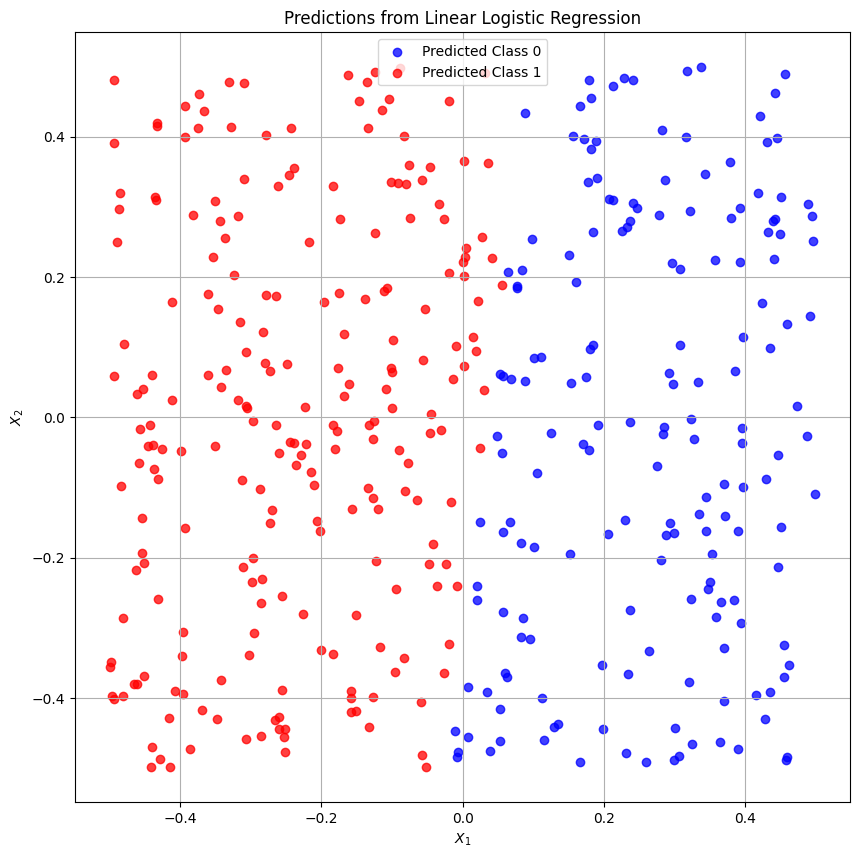

Training Accuracy: 0.50
Test Accuracy: 0.39


In [235]:

# (d) Predict and plot observations colored according to predicted class labels
y_pred_linear = log_reg.predict(X_train)
y_pred_linear_test = log_reg.predict(X_test)


plt.figure(figsize=(10, 10))
plt.scatter(X_train[:,0][y_pred_linear == 0], X_train[:,1][y_pred_linear == 0], color='blue', label='Predicted Class 0', alpha=0.75)
plt.scatter(X_train[:,0][y_pred_linear == 1], X_train[:,1][y_pred_linear == 1], color='red', label='Predicted Class 1', alpha=0.75)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True)
plt.title('Predictions from Linear Logistic Regression')
plt.legend()
plt.show()

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_pred_linear)
test_accuracy = accuracy_score(y_test, y_pred_linear_test)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")


In [236]:

# (e) Fit logistic regression with non-linear transformations
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)
X_poly_test = poly.fit_transform(X_test)
log_reg_nonlinear = LogisticRegression()
log_reg_nonlinear.fit(X_poly, y_train)


LogisticRegression()

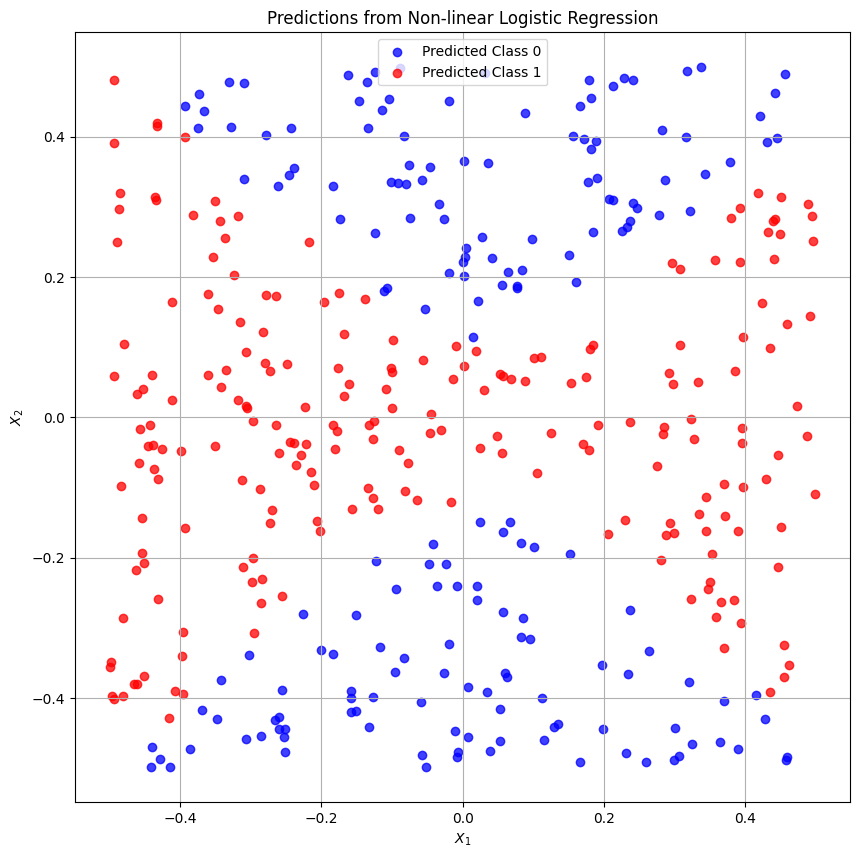

Training Accuracy: 0.94
Test Accuracy: 0.94


In [237]:

# (f) Predict and plot observations colored according to predicted class labels for non-linear logistic regression
y_pred_nonlinear = log_reg_nonlinear.predict(X_poly)
y_pred_nonlinear_test = log_reg_nonlinear.predict(X_poly_test)

plt.figure(figsize=(10, 10))
plt.scatter(X_train[:,0][y_pred_nonlinear == 0], X_train[:,1][y_pred_nonlinear == 0], color='blue', label='Predicted Class 0', alpha=0.75)
plt.scatter(X_train[:,0][y_pred_nonlinear == 1], X_train[:,1][y_pred_nonlinear == 1], color='red', label='Predicted Class 1', alpha=0.75)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True)
plt.title('Predictions from Non-linear Logistic Regression')
plt.legend()
plt.show()

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_pred_nonlinear)
test_accuracy = accuracy_score(y_test, y_pred_nonlinear_test)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

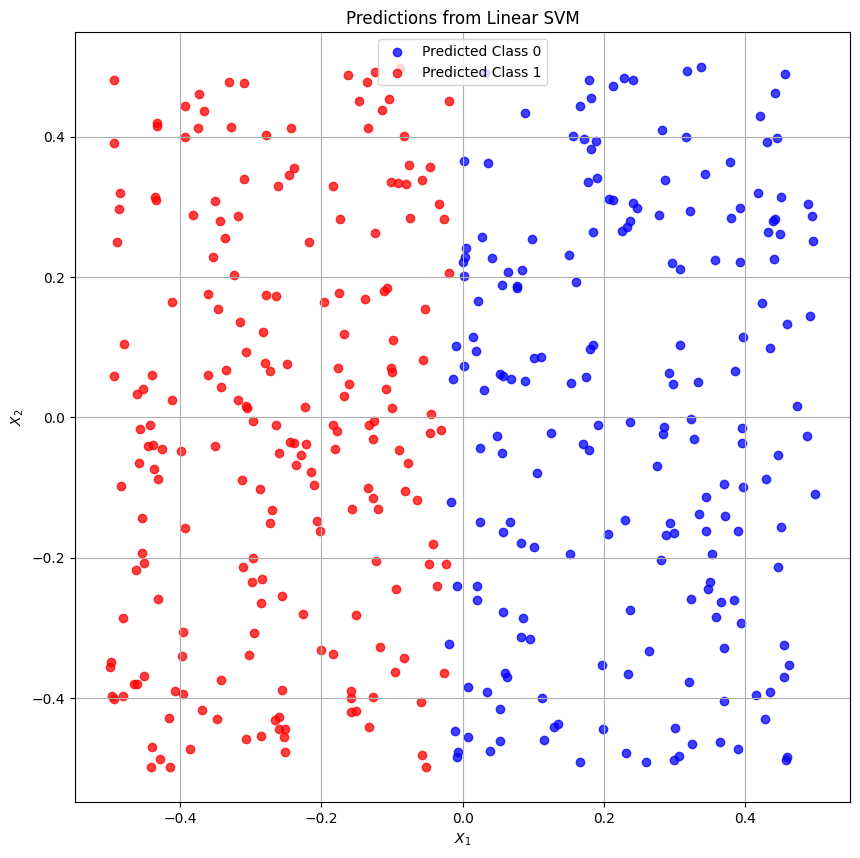

Training Accuracy: 0.56
Test Accuracy: 0.47


In [128]:

# (g) Fit a Support Vector Classifier (SVC) with linear kernel
svc_linear = SVC(kernel='linear', gamma=1, C=1, random_state=0, probability=True)
svc_linear.fit(X_train, y_train)

# Predict and plot observations for linear SVM
y_pred_svc_linear = svc_linear.predict(X_train)
y_pred_svc_linear_test = svc_linear.predict(X_test)

plt.figure(figsize=(10, 10))
plt.scatter(X_train[:,0][y_pred_svc_linear == 0], X_train[:,1][y_pred_svc_linear == 0], color='blue', label='Predicted Class 0', alpha=0.75)
plt.scatter(X_train[:,0][y_pred_svc_linear == 1], X_train[:,1][y_pred_svc_linear == 1], color='red', label='Predicted Class 1', alpha=0.75)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True)
plt.title('Predictions from Linear SVM')
plt.legend()
plt.show()

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_pred_svc_linear)
test_accuracy = accuracy_score(y_test, y_pred_svc_linear_test)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

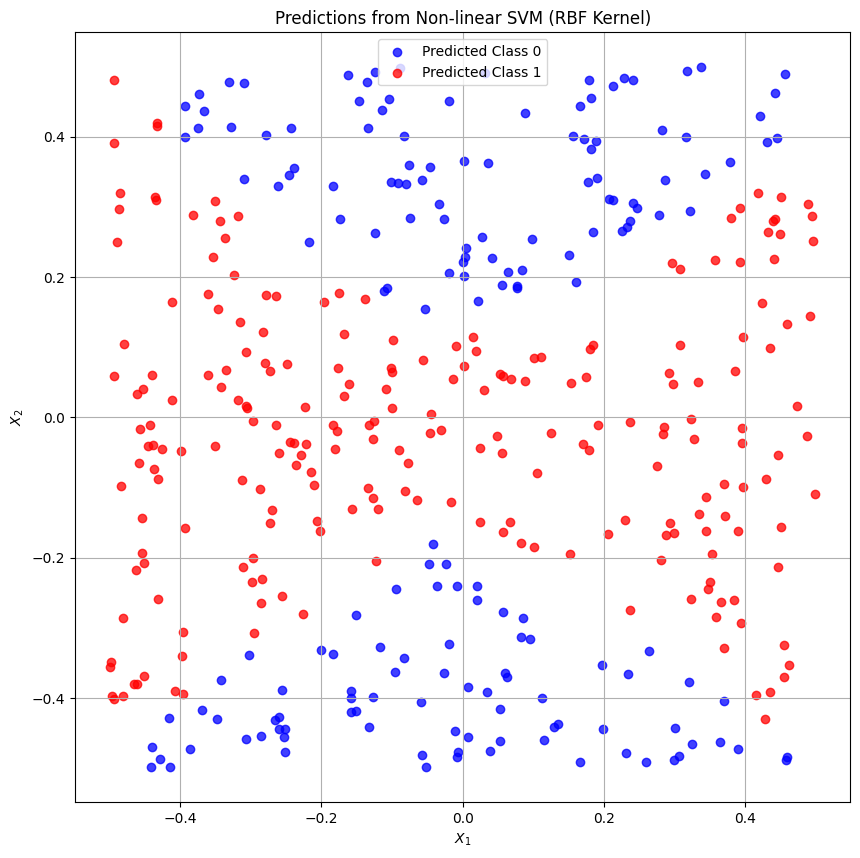

Training Accuracy: 0.92
Test Accuracy: 0.92


In [129]:

# (h) Fit a SVM with non-linear (RBF) kernel
svc_nonlinear = SVC(kernel='rbf', gamma=1, C=1, random_state=0, probability=True)
svc_nonlinear.fit(X_train, y_train)

# Predict and plot observations for non-linear SVM
y_pred_svc_nonlinear = svc_nonlinear.predict(X_train)
y_pred_svc_nonlinear_test = svc_nonlinear.predict(X_test)

plt.figure(figsize=(10, 10))
plt.scatter(X_train[:,0][y_pred_svc_nonlinear == 0], X_train[:,1][y_pred_svc_nonlinear == 0], color='blue', label='Predicted Class 0', alpha=0.75)
plt.scatter(X_train[:,0][y_pred_svc_nonlinear == 1], X_train[:,1][y_pred_svc_nonlinear == 1], color='red', label='Predicted Class 1', alpha=0.75)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True)
plt.title('Predictions from Non-linear SVM (RBF Kernel)')
plt.legend()
plt.show()

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_pred_svc_nonlinear)
test_accuracy = accuracy_score(y_test, y_pred_svc_nonlinear_test)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

(i)

Polynomial logistic regression and SVM with radial kernel achieve similar fits to the data. The logistic regression performs slightly better (94% test accuracy) than the SVM with a ratial kernel (92% test accuracy).

The linear support vector classifier achieves poor results because the seperation between classes is far from linear.

### Question 9.7

In [240]:
# Load the Auto dataset
data = load_data("Auto")

# (a) Create a binary variable for gas mileage above/below the median
median_mpg = data['mpg'].median()
data['HighMPG'] = (data['mpg'] > median_mpg).astype(int)
data=data.drop(columns=['mpg'])


In [241]:
# Part (b)

f = 'HighMPG ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)'
y, X = pt.dmatrices(f, data)

# Scale data
X = preprocessing.scale(X)
y = np.ravel(y)

costs = np.logspace(-5, 2, 20)
scores = []
for i in costs:
    # Get cv score 
    model = svm.SVC(kernel='linear', C=i, random_state=0)
    score = np.mean(cross_val_score(model, preprocessing.scale(X), y, cv=5))
    scores += [[i, score]]

columns=['Cost', 'CV_accuracy']
results_df = pd.DataFrame(data=np.asarray(scores), columns=columns)

display(results_df)

,Cost,CV_accuracy
0,0.000010,0.630802
1,0.000023,0.630802
2,0.000055,0.630802
3,0.000127,0.630802
4,0.000298,0.681435
5,0.000695,0.818306
6,0.001624,0.877215
7,0.003793,0.882376
8,0.008859,0.902889
9,0.020691,0.895326


Text(0.5, 1.0, 'Cross-Validation Error vs Cost')

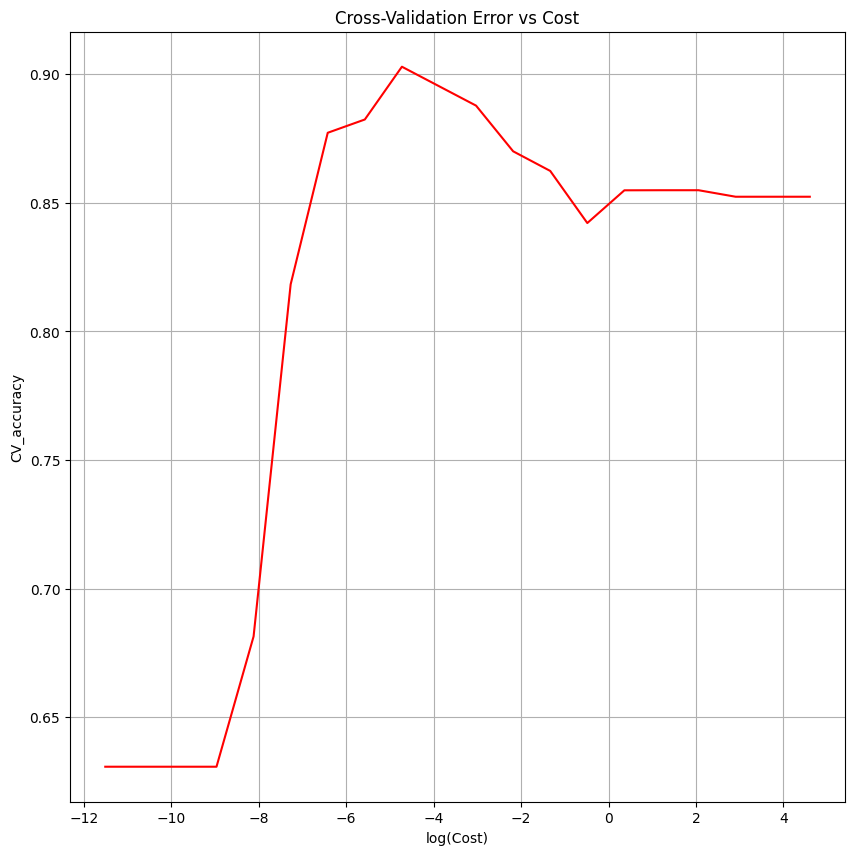

In [242]:
results_df['log(Cost)'] = np.log(results_df['Cost'])
plt.figure(figsize=(10,10))
sns.lineplot(x='log(Cost)', y='CV_accuracy', data=results_df, color = 'red')
plt.grid(True)
plt.title('Cross-Validation Error vs Cost')

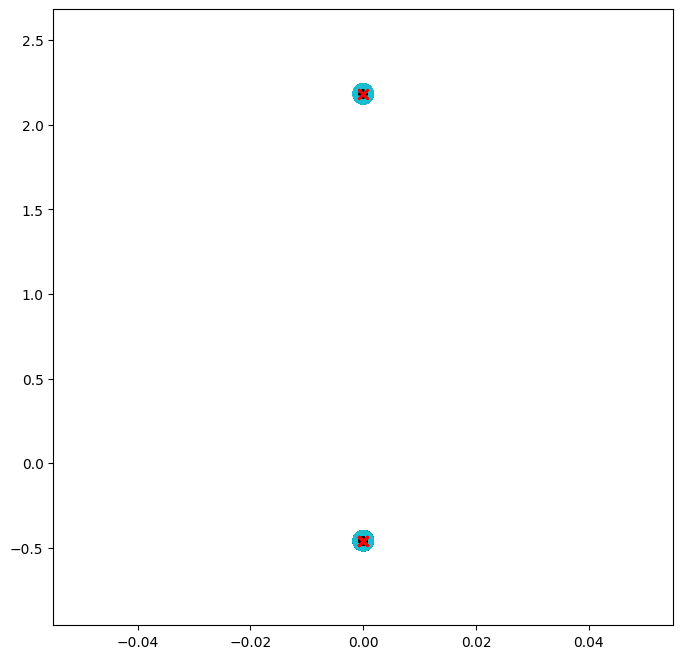

In [243]:
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X, y)

fig , ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_linear,ax=ax)

The log of cost that gives the best cross validation accuracy (which is the one with the lowest cross-validation error) is about -4.8. 

In [244]:
# Part (c)
C_range     = np.logspace(-5, 3, 10)
gamma_range = np.logspace(-5, 3, 10)
kernels     = ['rbf', 'poly']
degrees     = [3, 5, 7, 9]     # Using only odd values, because I noticed earlier evens are slow!
param_grid  = dict(gamma=gamma_range, C=C_range, kernel=kernels, degree=degrees)
rbf_grid = GridSearchCV(svm.SVC(cache_size=2000), param_grid=param_grid, cv=5, 
                        scoring='accuracy', return_train_score=True)
rbf_grid.fit(X, y)

GridSearchCV(cv=5, estimator=SVC(cache_size=2000),
             param_grid={'C': array([1.00000000e-05, 7.74263683e-05, 5.99484250e-04, 4.64158883e-03,
       3.59381366e-02, 2.78255940e-01, 2.15443469e+00, 1.66810054e+01,
       1.29154967e+02, 1.00000000e+03]),
                         'degree': [3, 5, 7, 9],
                         'gamma': array([1.00000000e-05, 7.74263683e-05, 5.99484250e-04, 4.64158883e-03,
       3.59381366e-02, 2.78255940e-01, 2.15443469e+00, 1.66810054e+01,
       1.29154967e+02, 1.00000000e+03]),
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [245]:
svc_linear = SVC(C=2.154434690031882, cache_size=2000, gamma=0.004641588833612777)
svc_linear.fit(X, y)

# Evaluate on test set
y_pred_scv_linear = svc_linear.predict(X)
print("\nClassification Report (Linear Kernel):")
print(classification_report(y, y_pred_scv_linear))


Classification Report (Linear Kernel):
              precision    recall  f1-score   support

         0.0       0.95      0.87      0.91       196
         1.0       0.88      0.95      0.92       196

    accuracy                           0.91       392
   macro avg       0.92      0.91      0.91       392
weighted avg       0.92      0.91      0.91       392



The best parameters for the SVMs with radial and polynomial basis kernels is C=2.154434690031882, cache_size=2000, gamma=0.004641588833612777. It has the best accuracy among the other competing models.

In [246]:
pd.DataFrame(rbf_grid.cv_results_).sort_values('rank_test_score', ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_degree,param_gamma,param_kernel,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
526,0.000977,0.001256,0.000000,0.000000,2.154435,7,0.004642,rbf,"{'C': 2.154434690031882, 'degree': 7, 'gamma':...",0.936709,...,0.902921,0.027958,1,0.916933,0.907348,0.923567,0.910828,0.917197,0.915175,0.005617
486,0.003463,0.004336,0.000478,0.000957,2.154435,3,0.004642,rbf,"{'C': 2.154434690031882, 'degree': 3, 'gamma':...",0.936709,...,0.902921,0.027958,1,0.916933,0.907348,0.923567,0.910828,0.917197,0.915175,0.005617
546,0.004380,0.005378,0.001075,0.001481,2.154435,9,0.004642,rbf,"{'C': 2.154434690031882, 'degree': 9, 'gamma':...",0.936709,...,0.902921,0.027958,1,0.916933,0.907348,0.923567,0.910828,0.917197,0.915175,0.005617
506,0.001380,0.001691,0.003187,0.004254,2.154435,5,0.004642,rbf,"{'C': 2.154434690031882, 'degree': 5, 'gamma':...",0.936709,...,0.902921,0.027958,1,0.916933,0.907348,0.923567,0.910828,0.917197,0.915175,0.005617
390,0.006291,0.005972,0.002532,0.003349,0.035938,9,0.278256,rbf,"{'C': 0.03593813663804626, 'degree': 9, 'gamma...",0.949367,...,0.900325,0.033167,5,0.900958,0.907348,0.917197,0.910828,0.914013,0.910069,0.005610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,0.003502,0.002422,0.003105,0.002619,0.000077,7,1000.000000,rbf,"{'C': 7.742636826811278e-05, 'degree': 7, 'gam...",0.493671,...,0.497468,0.003101,777,0.501597,0.501597,1.000000,1.000000,1.000000,0.800639,0.244166
78,0.006051,0.006088,0.007015,0.003400,0.000010,9,1000.000000,rbf,"{'C': 1e-05, 'degree': 9, 'gamma': 1000.0, 'ke...",0.493671,...,0.497468,0.003101,777,0.501597,0.501597,1.000000,1.000000,1.000000,0.800639,0.244166
278,0.001188,0.001458,0.002842,0.003041,0.004642,5,1000.000000,rbf,"{'C': 0.004641588833612777, 'degree': 5, 'gamm...",0.493671,...,0.497468,0.003101,777,0.501597,0.501597,1.000000,1.000000,1.000000,0.800639,0.244166
158,0.003486,0.003662,0.004203,0.003632,0.000077,9,1000.000000,rbf,"{'C': 7.742636826811278e-05, 'degree': 9, 'gam...",0.493671,...,0.497468,0.003101,777,0.501597,0.501597,1.000000,1.000000,1.000000,0.800639,0.244166


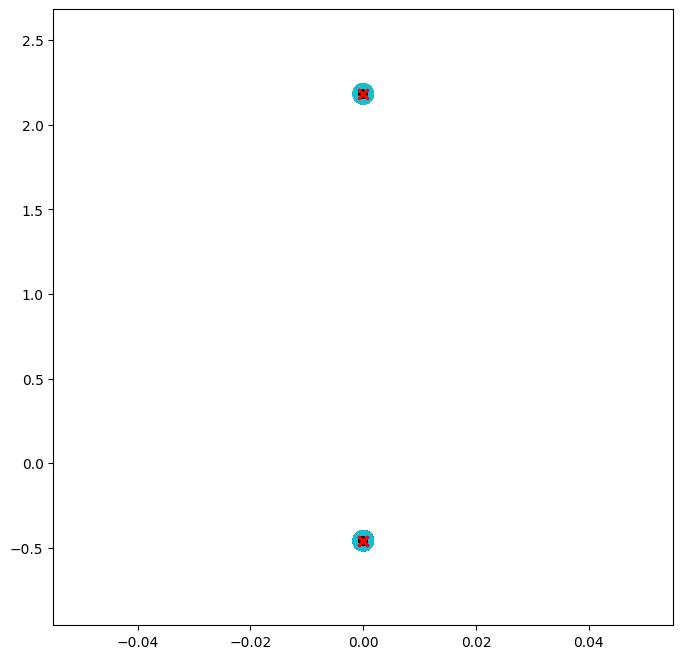

In [247]:
# Part (d)
X = pd.DataFrame(X)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,y, svc_linear, ax=ax, features=(0,1))
